2026-04-11 00:19:06 - src.features.selector - INFO - 特征选择结果已加载: ../output/models/lstm/selected_features.json
2026-04-11 00:19:06 - src.features.selector - INFO - 特征数: 53


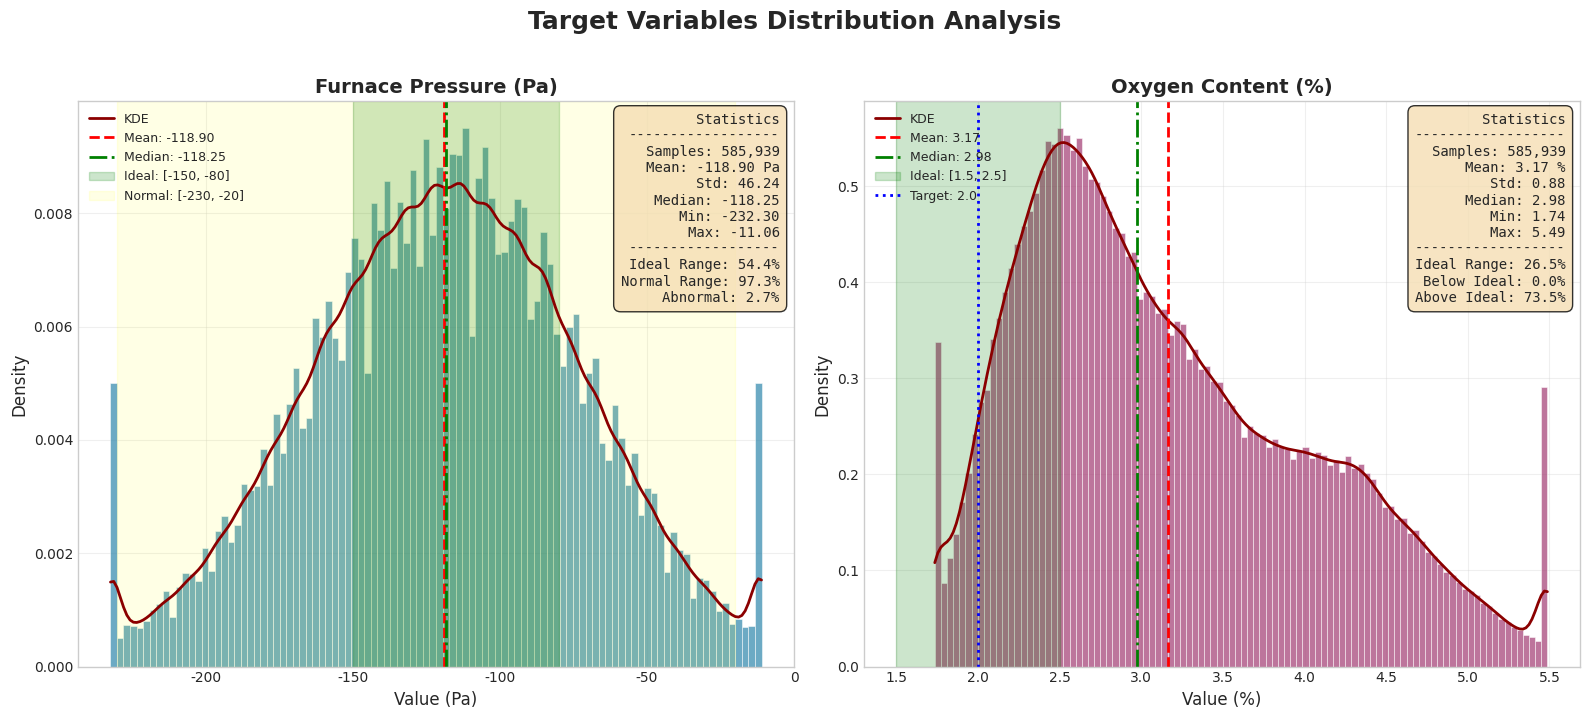


Target Variables Detailed Statistics

[炉膛压力 - Furnace Pressure (Pa)]
  Sample Count: 585,939
  Mean +/- Std: -118.90 +/- 46.24
  Median: -118.25
  Range: [-232.30, -11.06]
  Quartiles: Q1=-150.29, Q3=-86.59
  Ideal Range [-150, -80]: 318,734 samples (54.4%)
  Normal Range [-230, -20]: 569,925 samples (97.3%)
  Abnormal Range: 16,014 samples (2.7%)

[含氧量 - Oxygen Content (%)]
  Sample Count: 585,939
  Mean +/- Std: 3.17 +/- 0.88
  Median: 2.98
  Range: [1.74, 5.49]
  Quartiles: Q1=2.47, Q3=3.77
  Ideal Range [1.5, 2.5]: 155,289 samples (26.5%)


,2LB10CS001,APAFCDMD,2LB20CS001,BPAFCDMD,2LB30CS901,2LA30A11C01,2LB40CS901,2LA40A11C01,2NC10CS901,2NC10A11C01,...,2BK10CP004_trend_accel_20,MSFLOW_mean_30,DPU61AX108_mean_30,D66P53A10_mean_30,D61AX023_mean_30,2LA40A12C11_std_30,2LA40A12C11_mean_30,2LA30A12C11_mean_30,2BK10CP004,2BK10CQ1
0,1343.3018,99.0,1190.7233,95.0,747.101,97.0,600.3204,97.0,567.5923,96.0,...,NaN,259.420542,27.000000,876.709859,136825.607569,NaN,5.249713,8.315757,-27.8456,5.4879
1,1338.7245,99.0,1190.7233,95.0,747.101,97.0,600.3204,97.0,567.5923,96.0,...,0.00000,259.420542,27.000000,876.709859,136825.607569,0.0,5.249713,8.315757,-11.0619,5.4879
2,1327.1284,99.0,1190.7233,95.0,747.101,97.0,600.3204,97.0,567.5923,96.0,...,-0.98068,259.420542,28.333333,876.709859,136825.607569,0.0,5.249713,8.315757,-105.6607,5.4879


In [10]:
import sys
from pathlib import Path
sys.path.insert(0, '/home/lifazhi/boiler-draft-helper')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.config import MAIN_TARGETS, EXPERT_RANGES
from src.features.selector import FeatureSelector
import matplotlib as mpl

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# 加载数据
data_path = Path('../output/all_data_cleaned.feather')
feature_path = Path('../output/features/feature_matrix.feather')
selection_path = Path('../output/models/lstm/selected_features.json')
data = pd.read_feather(data_path)
features = pd.read_feather(feature_path)
selector = FeatureSelector(features, MAIN_TARGETS)
selected = selector.load_results(selection_path)["selected_features"]
selected = [f for f in selected if f in features.columns]
final_data = features[selected + MAIN_TARGETS]

target = final_data[MAIN_TARGETS]

# 目标变量配置
target_config = {
    '2BK10CP004': {
        'name': 'Furnace Pressure (Pa)',
        'name_cn': '炉膛压力',
        'unit': 'Pa',
        'ideal_range': EXPERT_RANGES['pressure_ideal'],
        'normal_range': EXPERT_RANGES['pressure_normal'],
        'color': '#2E86AB'
    },
    '2BK10CQ1': {
        'name': 'Oxygen Content (%)',
        'name_cn': '含氧量',
        'unit': '%',
        'ideal_range': EXPERT_RANGES['oxygen_ideal'],
        'normal_range': None,
        'target': EXPERT_RANGES['oxygen_target'],
        'color': '#A23B72'
    }
}

# 创建图表
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Target Variables Distribution Analysis', fontsize=18, fontweight='bold', y=1.02)

for idx, col in enumerate(MAIN_TARGETS):
    ax = axes[idx]
    config = target_config[col]
    data_col = target[col].dropna()
    
    # 计算统计量
    mean_val = data_col.mean()
    std_val = data_col.std()
    median_val = data_col.median()
    min_val = data_col.min()
    max_val = data_col.max()
    
    # 绘制直方图
    n, bins, patches = ax.hist(data_col, bins=100, density=True, alpha=0.7, 
                                color=config['color'], edgecolor='white', linewidth=0.5)
    
    # 添加KDE曲线
    from scipy import stats
    kde = stats.gaussian_kde(data_col)
    x_range = np.linspace(data_col.min(), data_col.max(), 200)
    ax.plot(x_range, kde(x_range), color='darkred', linewidth=2, label='KDE')
    
    # 绘制均值线
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median: {median_val:.2f}')
    
    # 绘制理想范围
    ideal = config['ideal_range']
    ax.axvspan(ideal[0], ideal[1], alpha=0.2, color='green', label=f'Ideal: [{ideal[0]}, {ideal[1]}]')
    
    # 绘制正常范围（如果有）
    if config.get('normal_range'):
        normal = config['normal_range']
        ax.axvspan(normal[0], normal[1], alpha=0.1, color='yellow', label=f'Normal: [{normal[0]}, {normal[1]}]')
    
    # 绘制目标值（如果有）
    if config.get('target'):
        ax.axvline(config['target'], color='blue', linestyle=':', linewidth=2, 
                   label=f'Target: {config["target"]}')
    
    # 计算各区间占比
    total_count = len(data_col)
    in_ideal = ((data_col >= ideal[0]) & (data_col <= ideal[1])).sum()
    ideal_pct = in_ideal / total_count * 100
    
    if config.get('normal_range'):
        normal = config['normal_range']
        in_normal = ((data_col >= normal[0]) & (data_col <= normal[1])).sum()
        normal_pct = in_normal / total_count * 100
        abnormal_pct = 100 - normal_pct
    else:
        below_ideal = (data_col < ideal[0]).sum()
        above_ideal = (data_col > ideal[1]).sum()
        below_pct = below_ideal / total_count * 100
        above_pct = above_ideal / total_count * 100
        abnormal_pct = 100 - ideal_pct
    
    # 添加统计信息文本框
    stats_text = f"""Statistics
------------------
Samples: {total_count:,}
Mean: {mean_val:.2f} {config['unit']}
Std: {std_val:.2f}
Median: {median_val:.2f}
Min: {min_val:.2f}
Max: {max_val:.2f}
------------------
Ideal Range: {ideal_pct:.1f}%"""

    if config.get('normal_range'):
        stats_text += f"\nNormal Range: {normal_pct:.1f}%"
        stats_text += f"\nAbnormal: {abnormal_pct:.1f}%"
    else:
        stats_text += f"\nBelow Ideal: {below_pct:.1f}%"
        stats_text += f"\nAbove Ideal: {above_pct:.1f}%"
    
    props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=props, family='monospace')
    
    # 设置标题和标签
    ax.set_title(f'{config["name"]}', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Value ({config["unit"]})', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    
    # 添加网格
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印详细统计
print("\n" + "="*60)
print("Target Variables Detailed Statistics")
print("="*60)
for col in MAIN_TARGETS:
    config = target_config[col]
    data_col = target[col].dropna()
    ideal = config['ideal_range']
    
    print(f"\n[{config['name_cn']} - {config['name']}]")
    print(f"  Sample Count: {len(data_col):,}")
    print(f"  Mean +/- Std: {data_col.mean():.2f} +/- {data_col.std():.2f}")
    print(f"  Median: {data_col.median():.2f}")
    print(f"  Range: [{data_col.min():.2f}, {data_col.max():.2f}]")
    print(f"  Quartiles: Q1={data_col.quantile(0.25):.2f}, Q3={data_col.quantile(0.75):.2f}")
    
    in_ideal = ((data_col >= ideal[0]) & (data_col <= ideal[1])).sum()
    print(f"  Ideal Range [{ideal[0]}, {ideal[1]}]: {in_ideal:,} samples ({in_ideal/len(data_col)*100:.1f}%)")
    
    if config.get('normal_range'):
        normal = config['normal_range']
        in_normal = ((data_col >= normal[0]) & (data_col <= normal[1])).sum()
        print(f"  Normal Range [{normal[0]}, {normal[1]}]: {in_normal:,} samples ({in_normal/len(data_col)*100:.1f}%)")
        print(f"  Abnormal Range: {len(data_col)-in_normal:,} samples ({(len(data_col)-in_normal)/len(data_col)*100:.1f}%)")
print("="*60)

final_data.head(3)